# Demodulate Packed Full-Audio Pipeline (Chunked FPGA Processing)

This notebook processes the **entire audio file** by splitting it into fixed-size chunks and sending each chunk through the FPGA.

## Why we did this
Our HLS core processes a fixed number of samples per run:

```cpp
for (int i = 0; i < 1024; i++)
```

So instead of only processing the first 1024 samples of the WAV file, now we:

1. load the full audio file
2. split it into chunks of 1024 samples
3. modulate each chunk in software
4. pack `(modulated_sample, carrier_sample)` into one 64-bit AXI-Stream word
5. send each chunk through the FPGA
6. low-pass filter the FPGA output in software
7. concatenate all recovered chunks
8. save and visualize the full recovered audio

## Hardware assumptions
Your overlay should contain:
- `axi_dma`
- `demodulate_packed_0`

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pynq import Overlay, allocate
from scipy.io import wavfile
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (12, 4)
np.set_printoptions(suppress=True, precision=4)

## Configuration

In [2]:
CHUNK_N = 1024
BITSTREAM_PATH = "/home/xilinx/jupyter_notebooks/final_project/demodulate_packed.bit"
WAV_PATH = "/home/xilinx/jupyter_notebooks/final_project/input.wav"

DMA_NAME = "axi_dma"
IP_NAME = "demodulate_packed_0"

CARRIER_FREQ_HZ = 4000
LPF_CUTOFF_HZ = 2000

PRINT_IP_INFO = True
PLOT_SAMPLES = 4000
SAVE_PREFIX = "/home/xilinx/jupyter_notebooks/final_project"

## Helper functions

In [3]:
def normalize_audio(x):
    x = np.asarray(x, dtype=np.float32)
    peak = np.max(np.abs(x))
    if peak == 0:
        return x
    return x / peak

def pad_to_chunk_multiple(x, chunk_n):
    x = np.asarray(x, dtype=np.float32)
    remainder = len(x) % chunk_n
    if remainder == 0:
        return x, 0
    pad_len = chunk_n - remainder
    return np.pad(x, (0, pad_len), mode="constant"), pad_len

def pack_signal_and_carrier(signal_f32, carrier_f32):
    signal_f32 = np.asarray(signal_f32, dtype=np.float32)
    carrier_f32 = np.asarray(carrier_f32, dtype=np.float32)

    sig_u32 = signal_f32.view(np.uint32)
    car_u32 = carrier_f32.view(np.uint32)

    packed_u64 = (car_u32.astype(np.uint64) << 32) | sig_u32.astype(np.uint64)
    return packed_u64

def lowpass_fft(signal, sample_rate, cutoff_hz):
    spectrum = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1 / sample_rate)
    spectrum[freqs > cutoff_hz] = 0
    filtered = np.fft.irfft(spectrum, n=len(signal))
    return filtered.astype(np.float32)

def make_time_axis(num_samples, sample_rate):
    return np.arange(num_samples) / sample_rate

def save_wav_float(path, sample_rate, audio_float):
    audio_float = normalize_audio(audio_float)
    audio_int16 = np.int16(np.clip(audio_float, -1.0, 1.0) * 32767)
    wavfile.write(path, sample_rate, audio_int16)

def process_chunk_on_fpga(modulated_chunk, carrier_chunk, dma, ip, in_buffer, out_buffer):
    packed_input = pack_signal_and_carrier(modulated_chunk, carrier_chunk)
    in_buffer[:] = packed_input
    out_buffer[:] = 0.0

    in_buffer.flush()
    out_buffer.flush()

    dma.recvchannel.transfer(out_buffer)
    ip.write(0x00, 0x01)
    dma.sendchannel.transfer(in_buffer)

    dma.sendchannel.wait()
    dma.recvchannel.wait()

    out_buffer.invalidate()
    return np.copy(out_buffer)

## Load overlay

In [4]:
ol = Overlay(BITSTREAM_PATH)

if PRINT_IP_INFO:
    print("IP blocks:", list(ol.ip_dict.keys()))

dma = getattr(ol, DMA_NAME)
ip = getattr(ol, IP_NAME)

IP blocks: ['demodulate_packed_0', 'axi_dma', 'zynq_ultra_ps_e_0']


## Load full audio

In [5]:
rate, audio = wavfile.read(WAV_PATH)

if audio.ndim == 2:
    audio = audio.mean(axis=1)

audio = audio.astype(np.float32)

if np.max(np.abs(audio)) > 0:
    audio = audio / np.max(np.abs(audio))

audio = normalize_audio(audio)
original_len = len(audio)

audio_padded, pad_len = pad_to_chunk_multiple(audio, CHUNK_N)
num_chunks = len(audio_padded) // CHUNK_N

print("Sample rate:", rate)
print("Original samples:", original_len)
print("Padded samples:", len(audio_padded))
print("Pad length:", pad_len)
print("Chunk size:", CHUNK_N)
print("Number of chunks:", num_chunks)

Sample rate: 8000
Original samples: 23493
Padded samples: 23552
Pad length: 59
Chunk size: 1024
Number of chunks: 23


## Visualize and listen to the original full audio

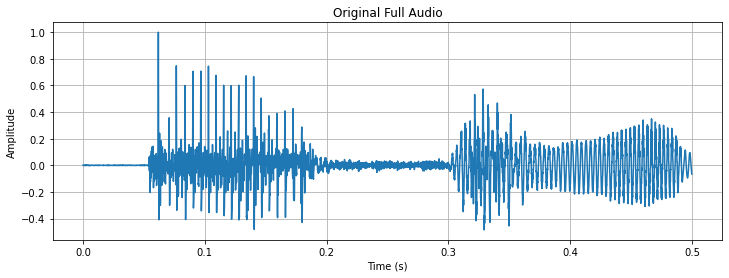

In [6]:
time_axis_full = make_time_axis(len(audio), rate)

plt.figure()
plt.plot(time_axis_full[:min(PLOT_SAMPLES, len(audio))], audio[:min(PLOT_SAMPLES, len(audio))])
plt.title("Original Full Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

display(Audio(audio, rate=rate))

## Allocate reusable DMA buffers
These buffers are reused for every chunk.

In [7]:
in_buffer = allocate(shape=(CHUNK_N,), dtype=np.uint64)
out_buffer = allocate(shape=(CHUNK_N,), dtype=np.float32)

## Process all chunks through the FPGA
For each chunk we:
- generate the carrier
- modulate in software
- send packed `(modulated, carrier)` data to FPGA
- get multiplied result back
- low-pass filter in software
- append recovered chunk

In [18]:
recovered_hw_chunks = []
recovered_sw_chunks = []
encrypted_chunks = []

total_hw_time = 0.0
total_sw_time = 0.0

for chunk_idx in range(num_chunks):
    start = chunk_idx * CHUNK_N
    end = start + CHUNK_N

    audio_chunk = audio_padded[start:end]

    t_chunk = np.arange(CHUNK_N) / rate
    carrier_chunk = np.cos(2 * np.pi * CARRIER_FREQ_HZ * t_chunk).astype(np.float32)

    # Encrypt / modulate in software
    modulated_chunk = audio_chunk * carrier_chunk
    encrypted_chunks.append(modulated_chunk)

    # Hardware multiply
    hw_start = time.perf_counter()
    mixed_back_hw_chunk = process_chunk_on_fpga(
        modulated_chunk, carrier_chunk, dma, ip, in_buffer, out_buffer
    )
    hw_end = time.perf_counter()
    total_hw_time += (hw_end - hw_start)

    # Software reference multiply
    sw_start = time.perf_counter()
    mixed_back_sw_chunk = modulated_chunk * carrier_chunk
    sw_end = time.perf_counter()
    total_sw_time += (sw_end - sw_start)


    # Low-pass filter in software
    demod_hw_chunk = 2.0 * lowpass_fft(mixed_back_hw_chunk, rate, LPF_CUTOFF_HZ)
    demod_sw_chunk = 2.0 * lowpass_fft(mixed_back_sw_chunk, rate, LPF_CUTOFF_HZ)

    recovered_hw_chunks.append(demod_hw_chunk)
    recovered_sw_chunks.append(demod_sw_chunk)

    if chunk_idx < 3:
        print(f"Processed chunk {chunk_idx+1}/{num_chunks}")

encrypted_full = np.concatenate(encrypted_chunks)
recovered_hw_full = np.concatenate(recovered_hw_chunks)
recovered_sw_full = np.concatenate(recovered_sw_chunks)

# Remove padding so output length matches original
encrypted_full = encrypted_full[:original_len]
recovered_hw_full = recovered_hw_full[:original_len]
recovered_sw_full = recovered_sw_full[:original_len]

# Normalize for listening and saving
audio_ref = normalize_audio(audio)
encrypted_full = normalize_audio(encrypted_full)
recovered_hw_full = normalize_audio(recovered_hw_full)
recovered_sw_full = normalize_audio(recovered_sw_full)

print("Finished processing all chunks.")
print("-" * 30)
# Calculate throughputs
hw_throughput = original_len / total_hw_time if total_hw_time > 0 else 0
sw_throughput = original_len / total_sw_time if total_sw_time > 0 else 0

print(f"Total HW Time: {total_hw_time:.4f}s | Throughput: {hw_throughput:,.0f} samples/s")
print(f"Total SW Time: {total_sw_time:.4f}s | Throughput: {sw_throughput:,.0f} samples/s")
print(f"Speedup: {sw_throughput / hw_throughput:.2f}x" if hw_throughput > 0 else "Speedup: N/A")

Processed chunk 1/23
Processed chunk 2/23
Processed chunk 3/23
Finished processing all chunks.
------------------------------
Total HW Time: 0.0201s | Throughput: 1,169,211 samples/s
Total SW Time: 0.0004s | Throughput: 58,244,700 samples/s
Speedup: 49.82x


## Compare hardware vs software recovered outputs

In [15]:
print(f"{'Metric':<25} | {'Value':<10}")
print("-" * 40)
print(f"{'Recovered-signal MSE':<25} | {mse_recovered:.6f}")
print(f"{'Recovered-signal Max err':<25} | {max_err_recovered:.6f}")

print("\nSample Comparison (First 10):")
print(f"{'Index':<6} | {'HW Sample':<12} | {'SW Sample':<12}")
for i in range(10):
    print(f"{i:<6} | {recovered_hw_full[i]:<12.4f} | {recovered_sw_full[i]:<12.4f}")


Metric                    | Value     
----------------------------------------
Recovered-signal MSE      | 0.000000
Recovered-signal Max err  | 0.000000

Sample Comparison (First 10):
Index  | HW Sample    | SW Sample   
0      | 0.1974       | 0.1974      
1      | -0.0672      | -0.0672     
2      | -0.0525      | -0.0525     
3      | 0.0430       | 0.0430      
4      | 0.0282       | 0.0282      
5      | -0.0310      | -0.0310     
6      | -0.0171      | -0.0171     
7      | 0.0249       | 0.0249      
8      | 0.0107       | 0.0107      
9      | -0.0227      | -0.0227     


## Visualize original vs encrypted vs decrypted (full audio)

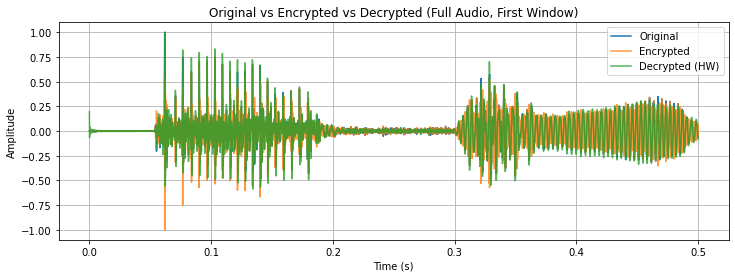

In [10]:
plot_n = min(PLOT_SAMPLES, len(audio_ref))
time_axis_plot = make_time_axis(plot_n, rate)

plt.figure()
plt.plot(time_axis_plot, audio_ref[:plot_n], label="Original")
plt.plot(time_axis_plot, encrypted_full[:plot_n], label="Encrypted", alpha=0.8)
plt.plot(time_axis_plot, recovered_hw_full[:plot_n], label="Decrypted (HW)", alpha=0.8)
plt.title("Original vs Encrypted vs Decrypted (Full Audio, First Window)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Visualize decrypted hardware vs software

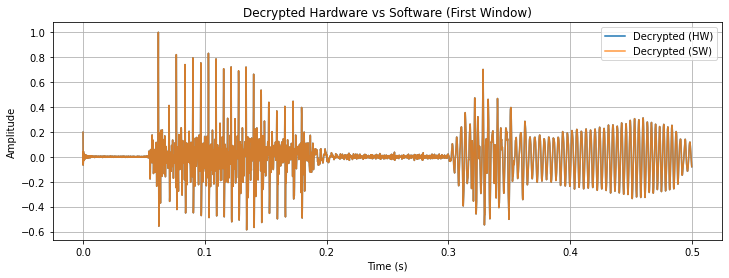

In [11]:
plt.figure()
plt.plot(time_axis_plot, recovered_hw_full[:plot_n], label="Decrypted (HW)")
plt.plot(time_axis_plot, recovered_sw_full[:plot_n], label="Decrypted (SW)", alpha=0.8)
plt.title("Decrypted Hardware vs Software (First Window)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Listen to full-audio results

In [12]:
print("Original full audio:")
display(Audio(audio_ref, rate=rate))

print("Encrypted / modulated full audio:")
display(Audio(encrypted_full, rate=rate))

print("Decrypted hardware full audio:")
display(Audio(recovered_hw_full, rate=rate))

print("Decrypted software full audio:")
display(Audio(recovered_sw_full, rate=rate))

Original full audio:


Encrypted / modulated full audio:


Decrypted hardware full audio:


Decrypted software full audio:


## Save output WAV files

In [13]:
save_wav_float(f"{SAVE_PREFIX}/encrypted_modulated_full.wav", rate, encrypted_full)
save_wav_float(f"{SAVE_PREFIX}/recovered_hw_full.wav", rate, recovered_hw_full)
save_wav_float(f"{SAVE_PREFIX}/recovered_sw_full.wav", rate, recovered_sw_full)

print("Saved:")
print(f"{SAVE_PREFIX}/encrypted_modulated_full.wav")
print(f"{SAVE_PREFIX}/recovered_hw_full.wav")
print(f"{SAVE_PREFIX}/recovered_sw_full.wav")

Saved:
/home/xilinx/jupyter_notebooks/final_project/encrypted_modulated_full.wav
/home/xilinx/jupyter_notebooks/final_project/recovered_hw_full.wav
/home/xilinx/jupyter_notebooks/final_project/recovered_sw_full.wav


## Cleanup

In [14]:
in_buffer.close()
out_buffer.close()
print("Buffers closed.")

Buffers closed.
